**CESAR - School**<br>
**Especialização: Engenharia e Análise de Dados** - **Turma:** 2025.2<br>
**RNA e Deep Learning**<br>
**Aula 2 - Exercício 6**

**Docente:** Vitor Casadei<br>
**Discente:** Caio Augustus Lima de Abreu Monteiro<br>


# Regressão Linear com PyTorch — Dataset KC House Data


## Objetivos


Este notebook adapta o exemplo de regressão linear (originalmente aplicado ao *Salary Dataset*) para o conjunto de dados **kc_house_data.csv**, que reúne registros de venda de imóveis no condado de King (Washington, EUA). O objetivo é estimar o **preço de venda** (`price`) de um imóvel a partir de suas características.

Mantêm-se os elementos centrais do código original:
- função de perda MSE do PyTorch (`nn.MSELoss`);
- treinamento dos parâmetros por gradiente descendente via otimizador (`optim.SGD`);
- modelo construído com uma camada `nn.Linear()`;
- divisão entre conjuntos de treinamento e validação.

Em relação ao dataset original, que dispunha de um único atributo preditor (`YearsExperience`), o conjunto de imóveis oferece diversas variáveis explicativas. Por essa razão, o notebook apresenta **duas abordagens complementares**:

1. **Regressão univariada** — utiliza apenas o atributo `sqft_living` (área construída), o preditor isolado mais correlacionado com o preço. Esta abordagem é diretamente análoga ao notebook original e permite a visualização da reta de ajuste em duas dimensões.
2. **Regressão multivariada** — utiliza um conjunto de atributos selecionados, explorando o potencial do dataset e demonstrando o ganho de desempenho proporcionado pela inclusão de múltiplas variáveis.

## Importação dos pacotes


In [5]:
%matplotlib inline
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)
np.random.seed(1234)

## Leitura e exploração dos dados


O arquivo `kc_house_data.csv` é carregado diretamente. Diferentemente do notebook original — que obtinha os dados via download do Kaggle —, o arquivo já se encontra disponível localmente.

In [6]:
# Carregamento do dataset
!curl -L -o /content/kc-house-data.zip https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction
!unzip -o /content/kc-house-data.zip

df = pd.read_csv('kc_house_data.csv')


print('Dimensões do dataset:', df.shape)
print('Valores ausentes:', df.isnull().sum().sum())
df.head()

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  1128k      0 --:--:-- --:--:-- --:--:-- 6496k
Archive:  /content/kc-house-data.zip
  inflating: kc_house_data.csv       
Dimensões do dataset: (21613, 21)
Valores ausentes: 0


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


### Análise de correlação

Antes da seleção dos atributos, examina-se a correlação linear de cada variável numérica com o preço, o que orienta a escolha dos preditores mais relevantes.

In [7]:
# Correlação das variáveis numéricas com o preço
num_cols = df.select_dtypes(include=['number']).drop(columns=['id'])
corr_price = num_cols.corr()['price'].sort_values(ascending=False)
print(corr_price)

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.525138
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
floors           0.256794
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


# Abordagem 1 — Regressão univariada (`sqft_living`)


Nesta primeira abordagem, utiliza-se exclusivamente o atributo `sqft_living` (área construída em pés quadrados), que apresenta a maior correlação individual com o preço (aproximadamente 0,70). A estrutura reproduz fielmente o notebook original, com um único atributo de entrada.

### Preparação e normalização dos dados


Os atributos de entrada e a variável-alvo são padronizados com `StandardScaler` (média zero e desvio-padrão unitário). A normalização é essencial para o bom condicionamento do gradiente descendente, especialmente quando as variáveis possuem escalas muito distintas — o que se acentuará na abordagem multivariada.

In [8]:
# Seleção do atributo e do alvo
X = df[['sqft_living']].values.astype(np.float32)
y = df[['price']].values.astype(np.float32)

# Normalização
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [9]:
# Divisão treino/validação (70/30)
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y_scaled, test_size=0.3, random_state=42)

# Conversão para tensores
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print('X_train_tensor shape:', X_train_tensor.shape)
print('y_train_tensor shape:', y_train_tensor.shape)
print('X_val_tensor shape:', X_val_tensor.shape)
print('y_val_tensor shape:', y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 1])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 1])
y_val_tensor shape: torch.Size([6484, 1])


### Criação do modelo


O modelo é uma camada linear com um atributo de entrada e uma saída. Mantém-se o termo de *bias* (diferentemente dos notebooks anteriores, em que o *bias* era incorporado como coluna de uns na matriz de entrada).

In [10]:
model = torch.nn.Linear(1, 1)

In [11]:
# Inspeção dos parâmetros inicializados
print('Peso inicial:', model.weight.data)
print('Bias inicial:', model.bias.data)

Peso inicial: tensor([[-0.9420]])
Bias inicial: tensor([-0.1962])


### Definição da função de perda e do otimizador


A taxa de aprendizado foi ajustada para `0.05`. O valor original (`0.3`), apropriado para o dataset reduzido de salários, mostrou-se elevado para este conjunto, de dimensão consideravelmente maior; a redução assegura uma convergência estável.

In [12]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.05)

### Laço de treinamento


As funções `train_epoch` e `validate_epoch` encapsulam, respectivamente, uma época de treinamento (com atualização de parâmetros) e a avaliação no conjunto de validação (sem cálculo de gradientes). Essa organização reproduz a estrutura do notebook original.

In [13]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train()  # modo de treinamento
    optimizer.zero_grad()

    # forward
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # backward e atualização
    loss.backward()
    optimizer.step()

    return loss.item()

In [14]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval()  # modo de avaliação
    with torch.no_grad():  # desativa o cálculo de gradientes
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item()

In [15]:
num_epochs = 200
w0_list = []  # armazena o peso (weight)
w1_list = []  # armazena o bias
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # treinamento
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # validação
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # armazena parâmetros para visualização posterior
    w0_list.append(model.weight.data[0][0].item())
    if model.bias is not None:
        w1_list.append(model.bias.data[0].item())
    else:
        w1_list.append(0.0)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[20/200], Train Loss: 0.540062, Val Loss: 0.602005
Epoch[40/200], Train Loss: 0.488412, Val Loss: 0.554085
Epoch[60/200], Train Loss: 0.487592, Val Loss: 0.552921
Epoch[80/200], Train Loss: 0.487579, Val Loss: 0.552851
Epoch[100/200], Train Loss: 0.487578, Val Loss: 0.552844
Epoch[120/200], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[140/200], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[160/200], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[180/200], Train Loss: 0.487578, Val Loss: 0.552843
Epoch[200/200], Train Loss: 0.487578, Val Loss: 0.552843


### Avaliação


A reta de ajuste é sobreposta aos dados de treinamento e validação (em escala normalizada). Como há um único atributo, a visualização bidimensional é direta.

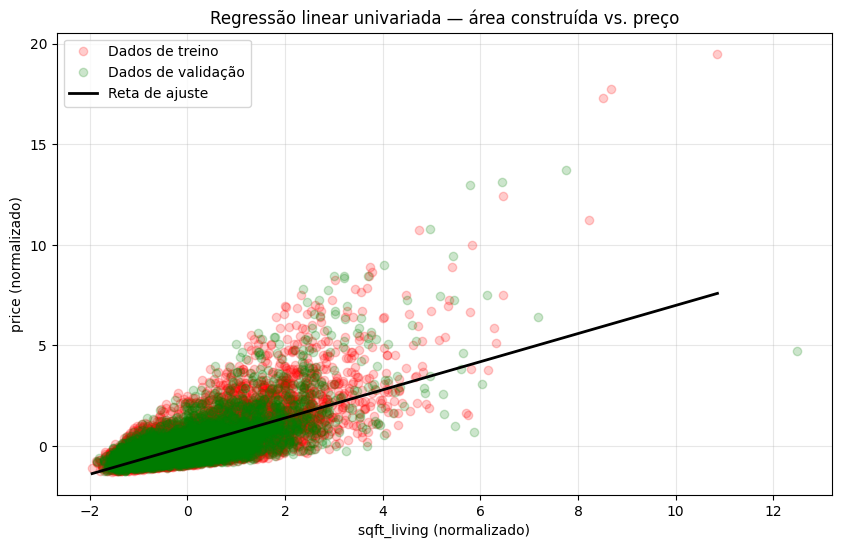

In [16]:
model.eval()
with torch.no_grad():
    y_pred_train = model(X_train_tensor)
    y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))
plt.plot(X_train_tensor.numpy(), y_train_tensor.numpy(), 'ro', alpha=0.2, label='Dados de treino')
plt.plot(X_val_tensor.numpy(), y_val_tensor.numpy(), 'go', alpha=0.2, label='Dados de validação')

# ordena para traçar a reta corretamente
order = np.argsort(X_train_tensor.numpy().ravel())
plt.plot(X_train_tensor.numpy().ravel()[order],
         y_pred_train.numpy().ravel()[order], 'k-', linewidth=2, label='Reta de ajuste')

plt.xlabel('sqft_living (normalizado)')
plt.ylabel('price (normalizado)')
plt.title('Regressão linear univariada — área construída vs. preço')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Curva de perda


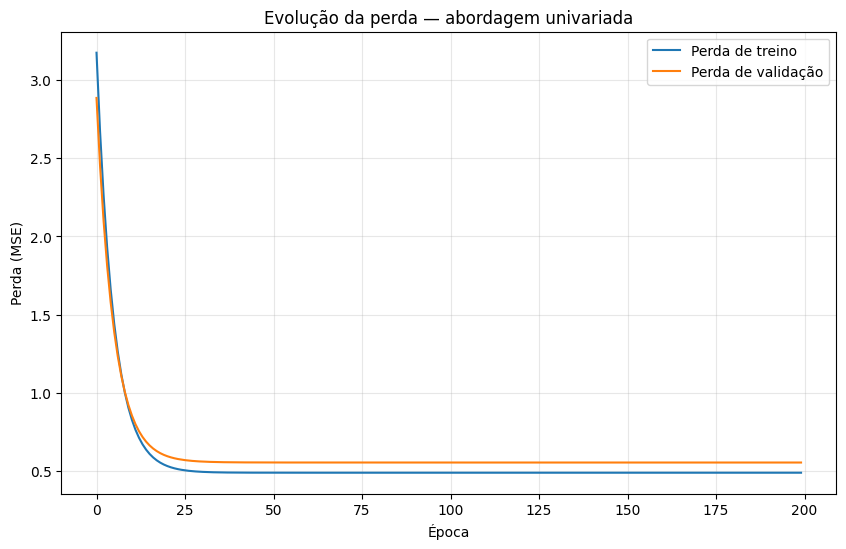

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Perda de treino')
plt.plot(range(num_epochs), val_losses, label='Perda de validação')
plt.xlabel('Época')
plt.ylabel('Perda (MSE)')
plt.title('Evolução da perda — abordagem univariada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Métrica de desempenho (R²)


Para quantificar a qualidade do ajuste, calcula-se o coeficiente de determinação $R^2$ no conjunto de validação. Esta métrica indica a proporção da variância do preço explicada pelo modelo.

In [18]:
def r2_score(y_true, y_pred):
    ss_res = ((y_true - y_pred) ** 2).sum()
    ss_tot = ((y_true - y_true.mean()) ** 2).sum()
    return 1 - ss_res / ss_tot

with torch.no_grad():
    y_pred_val_np = model(X_val_tensor).numpy()

r2_uni = r2_score(y_val, y_pred_val_np)
print(f'R2 (validação, univariada): {r2_uni:.4f}')

# RMSE convertido para a escala original (dólares)
y_std = y_scaler.scale_[0]
rmse_uni = np.sqrt(val_losses[-1]) * y_std
print(f'RMSE (validação): US$ {rmse_uni:,.0f}')

R2 (validação, univariada): 0.4839
RMSE (validação): US$ 272,965


# Abordagem 2 — Regressão multivariada


Esta abordagem explora o potencial do dataset ao incorporar múltiplos atributos preditores. A única alteração estrutural necessária no modelo é o número de atributos de entrada da camada `nn.Linear`, que passa a corresponder à quantidade de variáveis selecionadas. Todo o restante do procedimento — normalização, divisão treino/validação, função de perda e otimizador — permanece idêntico.

### Seleção de atributos e normalização


Foram selecionados doze atributos com correlação relevante com o preço, abrangendo dimensões físicas (área, número de cômodos), qualitativas (classificação de qualidade, vista) e de localização (latitude). Todos os atributos são padronizados, etapa indispensável em regressão multivariada, dado que as variáveis apresentam escalas heterogêneas (por exemplo, área em milhares de pés quadrados frente a contagens de cômodos).

In [19]:
features = ['sqft_living', 'grade', 'sqft_above', 'sqft_living15',
            'bathrooms', 'view', 'sqft_basement', 'bedrooms',
            'lat', 'waterfront', 'floors', 'yr_built']
print(f'Número de atributos: {len(features)}')

X_multi = df[features].values.astype(np.float32)
y_multi = df[['price']].values.astype(np.float32)

# Normalização
x_scaler_m = StandardScaler()
X_multi_scaled = x_scaler_m.fit_transform(X_multi)

y_scaler_m = StandardScaler()
y_multi_scaled = y_scaler_m.fit_transform(y_multi)

Número de atributos: 12


In [20]:
# Divisão treino/validação (70/30)
Xm_train, Xm_val, ym_train, ym_val = train_test_split(
    X_multi_scaled, y_multi_scaled, test_size=0.3, random_state=42)

Xm_train_tensor = torch.tensor(Xm_train, dtype=torch.float32)
ym_train_tensor = torch.tensor(ym_train, dtype=torch.float32)
Xm_val_tensor = torch.tensor(Xm_val, dtype=torch.float32)
ym_val_tensor = torch.tensor(ym_val, dtype=torch.float32)

print('Xm_train_tensor shape:', Xm_train_tensor.shape)
print('Xm_val_tensor shape:', Xm_val_tensor.shape)

Xm_train_tensor shape: torch.Size([15129, 12])
Xm_val_tensor shape: torch.Size([6484, 12])


### Criação do modelo multivariado


O modelo recebe agora `len(features)` atributos de entrada e produz uma única saída (o preço estimado).

In [21]:
model_multi = torch.nn.Linear(len(features), 1)
criterion_multi = nn.MSELoss()
optimizer_multi = optim.SGD(model_multi.parameters(), lr=0.05)

print('Formato dos pesos:', model_multi.weight.shape)

Formato dos pesos: torch.Size([1, 12])


### Laço de treinamento


As mesmas funções `train_epoch` e `validate_epoch` definidas anteriormente são reutilizadas, demonstrando que a transição de uma para múltiplas variáveis não exige alteração na lógica de treinamento.

In [22]:
num_epochs_m = 300
train_losses_m = []
val_losses_m = []

for epoch in range(num_epochs_m):
    train_loss = train_epoch(model_multi, optimizer_multi, criterion_multi,
                             Xm_train_tensor, ym_train_tensor)
    train_losses_m.append(train_loss)

    val_loss = validate_epoch(model_multi, criterion_multi,
                              Xm_val_tensor, ym_val_tensor)
    val_losses_m.append(val_loss)

    if (epoch + 1) % 30 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs_m}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[30/300], Train Loss: 0.321323, Val Loss: 0.352254
Epoch[60/300], Train Loss: 0.302679, Val Loss: 0.336046
Epoch[90/300], Train Loss: 0.299520, Val Loss: 0.333634
Epoch[120/300], Train Loss: 0.298904, Val Loss: 0.333312
Epoch[150/300], Train Loss: 0.298778, Val Loss: 0.333311
Epoch[180/300], Train Loss: 0.298752, Val Loss: 0.333337
Epoch[210/300], Train Loss: 0.298746, Val Loss: 0.333353
Epoch[240/300], Train Loss: 0.298745, Val Loss: 0.333361
Epoch[270/300], Train Loss: 0.298745, Val Loss: 0.333364
Epoch[300/300], Train Loss: 0.298744, Val Loss: 0.333365


### Curva de perda


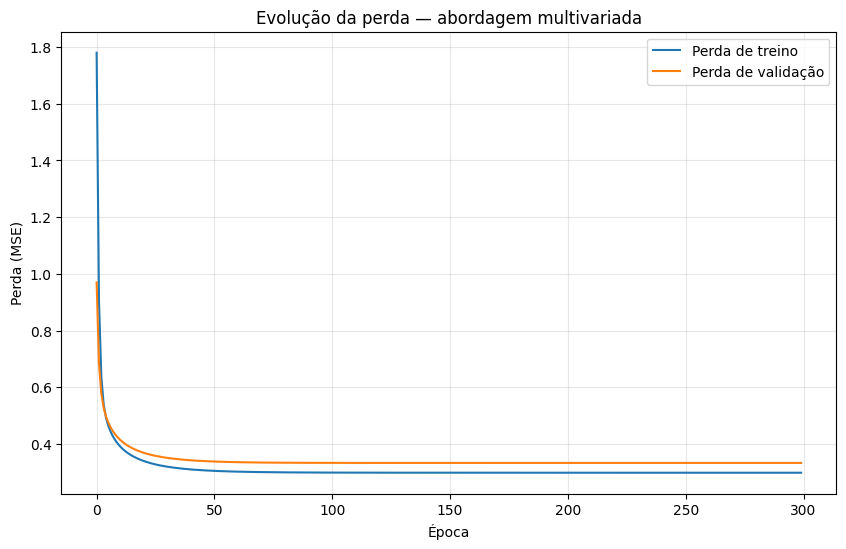

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs_m), train_losses_m, label='Perda de treino')
plt.plot(range(num_epochs_m), val_losses_m, label='Perda de validação')
plt.xlabel('Época')
plt.ylabel('Perda (MSE)')
plt.title('Evolução da perda — abordagem multivariada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Métrica de desempenho e valores preditos vs. reais


Calcula-se o $R^2$ do modelo multivariado e, em seguida, compara-se graficamente os valores preditos com os valores reais (em escala de dólares). Em um ajuste perfeito, os pontos se distribuiriam sobre a diagonal.

In [24]:
model_multi.eval()
with torch.no_grad():
    ym_pred_val_np = model_multi(Xm_val_tensor).numpy()

r2_multi = r2_score(ym_val, ym_pred_val_np)
print(f'R2 (validação, multivariada): {r2_multi:.4f}')

y_std_m = y_scaler_m.scale_[0]
rmse_multi = np.sqrt(val_losses_m[-1]) * y_std_m
print(f'RMSE (validação): US$ {rmse_multi:,.0f}')

R2 (validação, multivariada): 0.6888
RMSE (validação): US$ 211,966


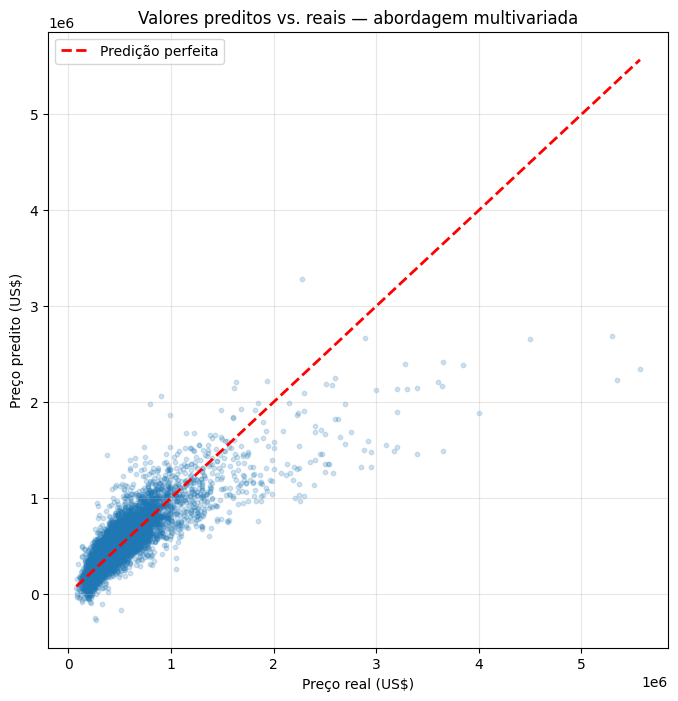

In [25]:
# Conversão das predições e dos valores reais para a escala original (dólares)
ym_pred_dollars = y_scaler_m.inverse_transform(ym_pred_val_np)
ym_real_dollars = y_scaler_m.inverse_transform(ym_val)

plt.figure(figsize=(8, 8))
plt.scatter(ym_real_dollars, ym_pred_dollars, alpha=0.2, s=10)
lim = [ym_real_dollars.min(), ym_real_dollars.max()]
plt.plot(lim, lim, 'r--', linewidth=2, label='Predição perfeita')
plt.xlabel('Preço real (US$)')
plt.ylabel('Preço predito (US$)')
plt.title('Valores preditos vs. reais — abordagem multivariada')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Considerações finais


A adaptação do notebook original para o conjunto **kc_house_data.csv** preservou integralmente a estrutura metodológica — modelo `nn.Linear`, perda `nn.MSELoss`, otimizador `optim.SGD` e divisão treino/validação —, demonstrando a generalidade do procedimento de regressão linear em PyTorch.

As adaptações necessárias foram pontuais e bem delimitadas:

- **Origem dos dados**: substituição do download via Kaggle pela leitura direta do arquivo local.
- **Seleção de atributos**: na abordagem univariada, escolha de `sqft_living` (maior correlação individual); na multivariada, seleção de doze atributos com base na análise de correlação.
- **Dimensão de entrada do modelo**: ajuste do primeiro argumento de `nn.Linear` de `1` para `len(features)`.
- **Taxa de aprendizado e número de épocas**: calibração para o volume de dados deste conjunto, consideravelmente maior que o original.

**Comparação de desempenho.** A abordagem univariada explicou aproximadamente 48% da variância do preço no conjunto de validação ($R^2 \approx 0{,}48$), ao passo que a multivariada elevou esse índice para cerca de 69% ($R^2 \approx 0{,}69$). O ganho evidencia que o preço de um imóvel é determinado por múltiplos fatores, e não apenas pela área construída — embora esta seja, isoladamente, o preditor mais influente.

**Limitações.** A regressão linear pressupõe relações lineares entre atributos e alvo. O gráfico de valores preditos versus reais sugere subestimação sistemática nos imóveis de maior valor, indício de não linearidades não capturadas pelo modelo. Estratégias para aprimoramento futuro incluem a transformação logarítmica do preço, a engenharia de novos atributos (como idade do imóvel) e o emprego de modelos não lineares — caminho natural rumo às redes neurais de maior profundidade abordadas na disciplina.